# Assignment:

1. Perform some movie recommendations and analysis for user 2:
- How many movies has this user watched?
- Plot a bar chart of their movie ratings. The bar chart should be the counts of the number of unique ratings.
    - Hint: the `sort_index()` function from pandas might be helpful to make the bar plot look nicer.
- What are some of user 2's top movies?
    - Hint: to get the actual movie titles, you can use pandas [merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) function, although using the movie IDs is OK too.
- Find the most similar user in the movielens dataset to user 2 using at least 2 distance metrics. Be sure to use cosine distance as one of your choices.
- Recommend a few movies for user 2 using similarity metrics.
- Do the recommendations from this method make sense?
- Write a short analysis of the results, and justify which similarity metric(s) you used.

Optional challenges:
- Perform other analyses (e.g. EDA, visualizations) of the movies watched from this dataset, or from a bigger part of the dataset for the movielens dataset: https://grouplens.org/datasets/movielens/
- Add yourself as a user in the data with ratings for movies you've watched, and find recommendations for next movies to watch. 
- Use a more advanced collaborative or content-based recommender to make recommendations (e.g. using the surprise package in Python)
    - Try making predictions for user 2. How do they compare with our basic model?
    - Add your own movie ratings, or use another recommender dataset and add your own preferences, then get recommendations for yourself

# Start the Solution

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.spatial.distance import pdist, squareform
import time

from surprise import SVD, BaselineOnly, Dataset, Reader, KNNBasic
from surprise.model_selection import cross_validate


## Import Data

In [2]:
movies = pd.read_csv('data/movies.csv')

In [3]:
ratings = pd.read_csv('data/ratings.csv')

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
ratings.userId.unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

## Filter data for user 2

In [7]:
user2_ratings = ratings[ratings.userId == 2]

In [8]:
user2_ratings.head()

,userId,movieId,rating,timestamp
232,2,318,3.0,1445714835
233,2,333,4.0,1445715029
234,2,1704,4.5,1445715228
235,2,3578,4.0,1445714885
236,2,6874,4.0,1445714952


## Count movies watched by user 2

In [9]:
user2_movies_watched_num = len(user2_ratings)

In [10]:
print(f"User 2 has watched {user2_movies_watched_num} movies.")

User 2 has watched 29 movies.


## Bar chart of User 2 movie ratings

In [11]:
user2_ratings_count = user2_ratings['rating'].value_counts().sort_index()

In [12]:
user2_ratings_count

rating
2.0    1
2.5    1
3.0    4
3.5    4
4.0    9
4.5    4
5.0    6
Name: count, dtype: int64

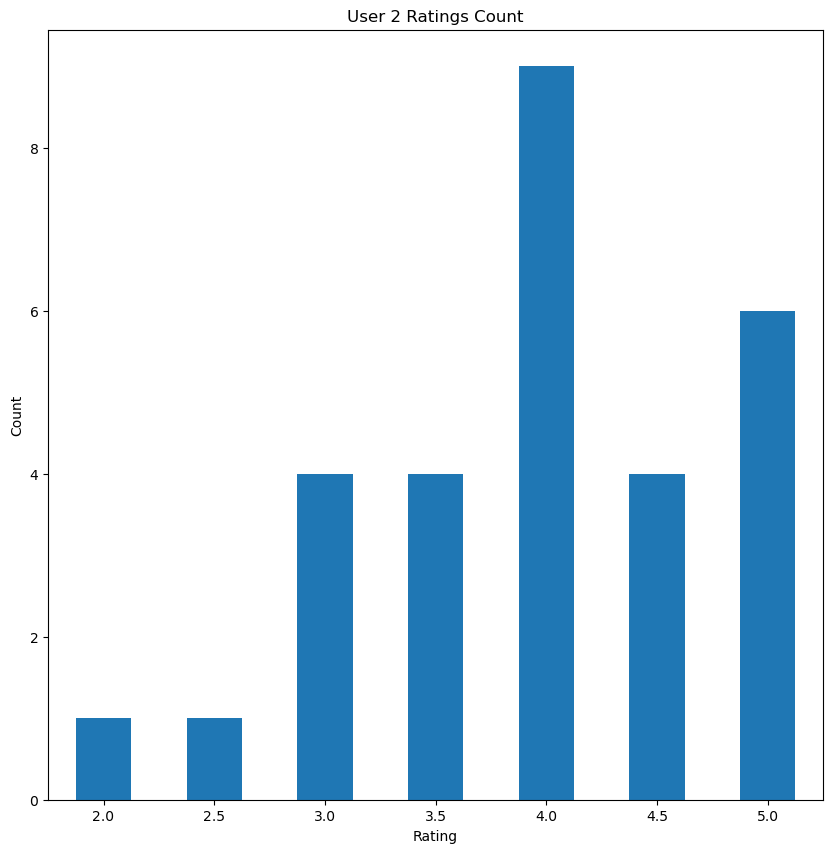

In [13]:
plt.figure(figsize=(10,10))
user2_ratings_count.plot.bar()
plt.title('User 2 Ratings Count')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## User 2's top movies

In [14]:
user2_top_rated_movies = user2_ratings.sort_values(['rating','movieId'], ascending=[False,True]).head(10)

In [15]:
user2_top_rated_movies = user2_top_rated_movies[['movieId', 'rating']].merge(movies[['movieId', 'title']], how='left', on='movieId')

In [16]:
user2_top_rated_movies[['movieId', 'title', 'rating']]

,movieId,title,rating
0,60756,Step Brothers (2008),5.0
1,80906,Inside Job (2010),5.0
2,89774,Warrior (2011),5.0
3,106782,"Wolf of Wall Street, The (2013)",5.0
4,122882,Mad Max: Fury Road (2015),5.0
5,131724,The Jinx: The Life and Deaths of Robert Durst ...,5.0
6,1704,Good Will Hunting (1997),4.5
7,58559,"Dark Knight, The (2008)",4.5
8,68157,Inglourious Basterds (2009),4.5
9,80489,"Town, The (2010)",4.5


## Find the most similar User to User2

### Prepare for Simillarity

In [17]:
movies.set_index('movieId', inplace=True)

In [18]:
movies_with_rating = pd.concat([movies, ratings.groupby('movieId').sum()], axis=1).sort_values(by='rating', ascending=False)

In [19]:
movies_with_rating = movies_with_rating.reset_index()

In [20]:
movies_with_rating.head()

,movieId,title,genres,userId,rating,timestamp
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,95829.0,1404.0,3.769248e+11
1,356,Forrest Gump (1994),Comedy|Drama|Romance|War,101385.0,1370.0,3.861652e+11
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,90621.0,1288.5,3.492043e+11
3,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,85236.0,1165.5,3.502700e+11
4,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,85535.0,1161.0,3.200357e+11


In [21]:
user_movie_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

In [22]:
user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
user_movie_matrix.fillna(-1, inplace=True)

In [24]:
user_cor = user_movie_matrix.T.corr()

In [25]:
user_cor.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.018916,0.059204,0.179894,0.121369,0.103828,0.141187,0.130393,0.052089,0.003243,...,0.064748,0.148329,0.191966,0.058442,0.135612,0.122529,0.259260,0.268676,0.086328,0.094546
2,0.018916,1.000000,-0.002936,-0.001895,0.015369,0.015436,0.025824,0.024174,-0.003570,0.065066,...,0.199690,0.010897,-0.004286,-0.005430,-0.008081,0.011038,0.006055,0.031115,0.025154,0.087520
3,0.059204,-0.002936,1.000000,-0.002646,0.007895,0.000028,-0.006534,0.007555,-0.003594,-0.006335,...,0.006577,0.005261,0.015396,-0.005467,0.003285,0.002749,0.019761,0.015210,-0.003342,0.014557
4,0.179894,-0.001895,-0.002646,1.000000,0.122238,0.069313,0.102479,0.060439,0.002010,0.018884,...,0.077143,0.116174,0.286354,0.041942,0.062982,0.165208,0.118940,0.124587,0.024487,0.060899
5,0.121369,0.015369,0.007895,0.122238,1.000000,0.298352,0.103712,0.429288,-0.004360,0.025950,...,0.060624,0.415991,0.098957,0.262230,0.141565,0.089978,0.149544,0.129392,0.256483,0.040026


### Simple Recommender

In [26]:
user_cor.loc[2].sort_values(ascending=False)

userId
2      1.000000
366    0.300528
378    0.277953
417    0.277085
550    0.252587
         ...   
234   -0.007649
605   -0.008081
312   -0.008135
104   -0.009044
217   -0.013622
Name: 2, Length: 610, dtype: float64

Check if two users have rated the same movies, then find the movies the first one has not watched from the second one.

In [27]:
user_cor.loc[2].notna().equals(user_cor.loc[366].notna())

True

We can get movies rated 5 by 366, but not rated by user 2 - these could be recommendations.

In [28]:
#We'll print movie ids that base_user in this case user 2has not watched
base_user = 2
compare_user = 366

In [29]:
# Filter movies rated by compare_user
compare_user_ratings = ratings[(ratings['userId'] == 366) & (ratings['rating'].notna())] # movies_with_rating[(movies_with_rating['userId'] == 366) & (movies_with_rating['rating'].notna())]

In [30]:
# Get movies rated by base_user
base_user_rated_movies = ratings[(ratings['userId'] == 2) & (ratings['rating'].notna())]['movieId'] # movies_with_rating[(movies_with_rating['userId'] == 2) & (movies_with_rating['rating'].notna())]['movieId']

In [31]:
# Filter out movies that base_user has rated from compare_user's ratings
movies_for_compare_user = compare_user_ratings[~compare_user_ratings['movieId'].isin(base_user_rated_movies)]['movieId'].to_list()
# movies_recommended = movies.loc[movies.index.isin(movies_for_compare_user)]
movies_recommended = movies_with_rating[movies_with_rating['movieId'].isin(movies_for_compare_user)]

In [32]:
user_base_movies_recommended = movies_recommended[['movieId', 'title','genres']].merge(
    ratings[ratings['userId'] == 366][['movieId', 'rating']], how='left', on='movieId').sort_values(['rating','movieId'], ascending=[False, True])

In [33]:
print("Here is list of Movies Recommended for User 2 based on User 366 (compare_user):")
display(user_base_movies_recommended.head(10))

Here is list of Movies Recommended for User 2 based on User 366 (compare_user):


,movieId,title,genres,rating
8,1089,Reservoir Dogs (1992),Crime|Mystery|Thriller,5.0
1,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.5
3,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.5
5,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.5
14,8368,Harry Potter and the Prisoner of Azkaban (2004),Adventure|Fantasy|IMAX,4.5
18,116797,The Imitation Game (2014),Drama|Thriller|War,4.5
0,110,Braveheart (1995),Action|Drama|War,4.0
2,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.0
7,1036,Die Hard (1988),Action|Crime|Thriller,4.0
4,2028,Saving Private Ryan (1998),Action|Drama|War,4.0


### Using Euclidean

In [34]:
user_movie_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

In [35]:
euclidean_distances = squareform(pdist(user_movie_matrix, metric='euclidean'))

In [36]:
euclidean_df = pd.DataFrame(data=euclidean_distances, columns=user_movie_matrix.index, index=user_movie_matrix.index)

In [37]:
euclidean_df.loc[2].sort_values().head(10)

userId
2       0.000000
442    22.627417
461    24.556058
508    24.627221
189    24.804234
293    25.005000
245    25.322915
431    25.426364
333    25.500000
433    25.519600
Name: 2, dtype: float64

In [38]:
most_similar_user_euclidean = euclidean_df.loc[2].sort_values().index[1]

In [39]:
print(f"Most similar user to user 2 based on Euclidean Distance: {most_similar_user_euclidean}")

Most similar user to user 2 based on Euclidean Distance: 442


In [40]:
# Recommendations based on Euclidean Distance (User 442)
similar_user_euclidean_ratings = ratings[ratings['userId'] == most_similar_user_euclidean]
recommended_movies_euclidean = similar_user_euclidean_ratings[similar_user_euclidean_ratings['rating'] >= 4.0]

display(recommended_movies_euclidean)

,userId,movieId,rating,timestamp


We can see there are no movies recommended by user 442 that have rating higher than 4. They haven't really recommended any movies really. Let us now look at the 2nd top similar users and get some recommendations

In [41]:
most_similar_user_euclidean2 = euclidean_df.loc[2].sort_values().index[2]
most_similar_user_euclidean2

461

In [42]:
similar_user_euclidean_ratings = ratings[ratings['userId'] == most_similar_user_euclidean2]
recommended_movies_euclidean = similar_user_euclidean_ratings[similar_user_euclidean_ratings['rating'] >= 4.0]

display(recommended_movies_euclidean)

,userId,movieId,rating,timestamp
71517,461,186,4.0,1505935426
71519,461,318,4.5,1505935213
71520,461,356,5.0,1505935220
71524,461,539,4.0,1505935378
71525,461,587,4.0,1505935387
71526,461,593,4.0,1505935264
71528,461,1213,4.0,1505935438
71529,461,1246,4.5,1505935259
71530,461,1259,4.0,1505935267
71531,461,1704,4.0,1505935222


the 2nd nearest user have rated movies higher than 4, hence that can be considered a good recommendation and going with that

In [43]:
recommended_movies_euclidean = recommended_movies_euclidean[~recommended_movies_euclidean['movieId'].isin(base_user_rated_movies)]

recommended_movies_euclidean = recommended_movies_euclidean.sort_values(by='rating', ascending=False)
recommended_movies_euclidean_with_titles = pd.merge(recommended_movies_euclidean, movies, on='movieId')
recommended_movies_euclidean_with_titles = recommended_movies_euclidean_with_titles[['movieId', 'title', 'genres', 'rating']]

In [44]:
print(f"Top movie recommendations for User 2 based on Euclidean Distance (from 2nd most similar User {most_similar_user_euclidean2}):")
display(recommended_movies_euclidean_with_titles)

Top movie recommendations for User 2 based on Euclidean Distance (from 2nd most similar User 461):


,movieId,title,genres,rating
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War,5.0
1,1246,Dead Poets Society (1989),Drama,4.5
2,1784,As Good as It Gets (1997),Comedy|Drama|Romance,4.5
3,186,Nine Months (1995),Comedy|Romance,4.0
4,539,Sleepless in Seattle (1993),Comedy|Drama|Romance,4.0
5,587,Ghost (1990),Comedy|Drama|Fantasy|Romance|Thriller,4.0
6,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.0
7,1213,Goodfellas (1990),Crime|Drama,4.0
8,1259,Stand by Me (1986),Adventure|Drama,4.0
9,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery,4.0


### Cosine

In [45]:
cosine_distances = squareform(pdist(user_movie_matrix, metric='cosine'))
cosine_df = pd.DataFrame(cosine_distances, columns=user_movie_matrix.index, index=user_movie_matrix.index)
cosine_df.loc[2].sort_values().head(10)

userId
2      0.000000
366    0.699926
417    0.719575
378    0.723990
550    0.745843
189    0.757503
528    0.758508
495    0.759668
461    0.760704
279    0.763914
Name: 2, dtype: float64

In [46]:
most_similar_user_cosine = cosine_df.loc[2].sort_values().index[1]
most_similar_user_cosine

366

We can see that most similar user between cosine and simple correlation is same (user 366), whereas they differ for Euclidean distance user 442

In [47]:
print(f"Top movie recommendations for User 2 based on Cosine Similarity (from User {most_similar_user_cosine}):")
display(user_base_movies_recommended.head(10))

Top movie recommendations for User 2 based on Cosine Similarity (from User 366):


,movieId,title,genres,rating
8,1089,Reservoir Dogs (1992),Crime|Mystery|Thriller,5.0
1,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.5
3,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.5
5,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.5
14,8368,Harry Potter and the Prisoner of Azkaban (2004),Adventure|Fantasy|IMAX,4.5
18,116797,The Imitation Game (2014),Drama|Thriller|War,4.5
0,110,Braveheart (1995),Action|Drama|War,4.0
2,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.0
7,1036,Die Hard (1988),Action|Crime|Thriller,4.0
4,2028,Saving Private Ryan (1998),Action|Drama|War,4.0


## Summary

* User 2 has rated 29 movies in the dataset. User 2's rating distribution is skewed towards higher ratings.
* User 2's top 10 rated movies include a mix of genres, with several action/thriller and drama films.
* The most similar user to User 2 differs depending on the similarity metric: User 366 for Cosine Similarity & Simple correlation and User 442 for Euclidean Distance (as user 442 didn't highly recommended any movies, we used the next best user (461) to find a few recommendations).

## Optional Tasks

In [48]:
ratings.sort_values(['userId', 'movieId'], ascending=[False, False]).head()

,userId,movieId,rating,timestamp
100835,610,170875,3.0,1493846415
100834,610,168252,5.0,1493846352
100833,610,168250,5.0,1494273047
100832,610,168248,5.0,1493850091
100831,610,166534,4.0,1493848402


### Perform other analyses

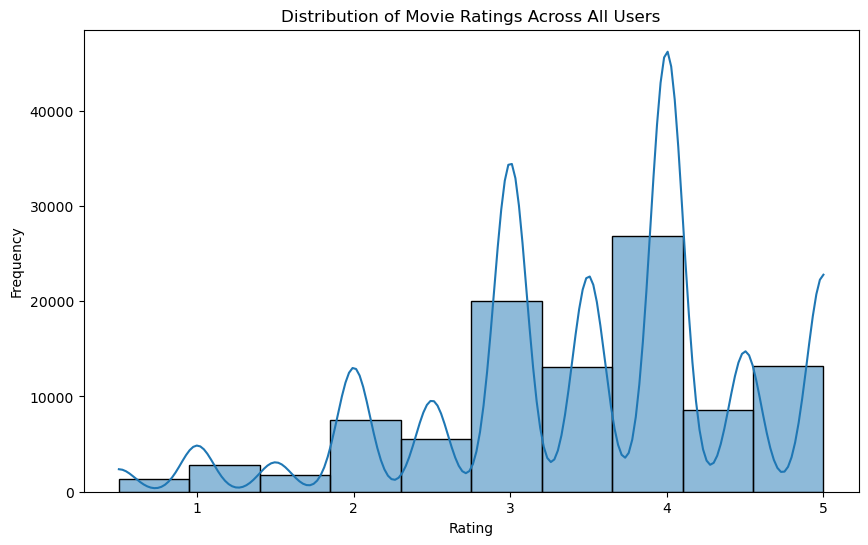

In [49]:
# Analyze the distribution of movie ratings across all users.
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title('Distribution of Movie Ratings Across All Users')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

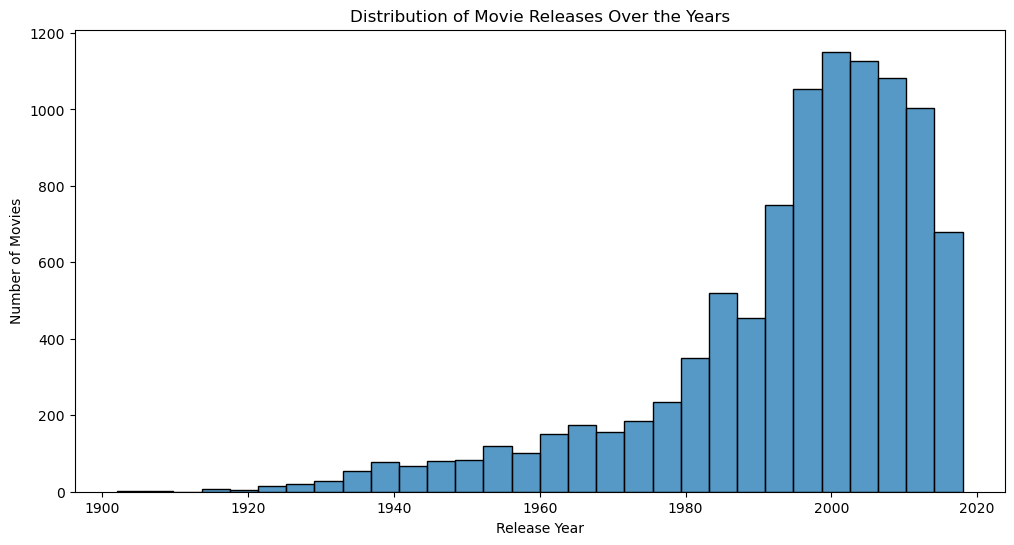

In [50]:
# Extract year from movie titles
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

plt.figure(figsize=(12, 6))
sns.histplot(movies['year'].dropna(), bins=30, kde=False)
plt.title('Distribution of Movie Releases Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.show()

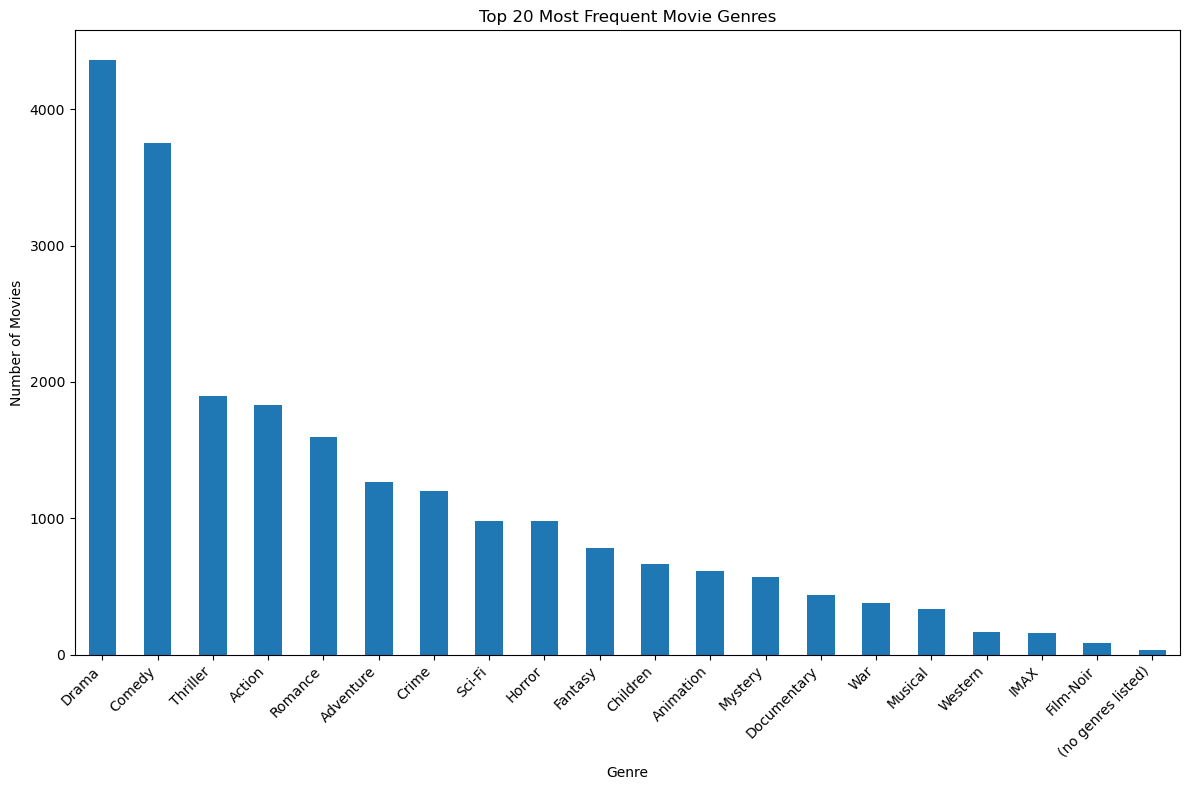

In [51]:
# Split genres and count occurrences
genres = movies['genres'].str.split('|', expand=True).stack()
genre_counts = genres.value_counts()

plt.figure(figsize=(12, 8))
genre_counts.head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Exploratory Data Analysis Summary

**Rating Distribution:** The distribution of movie ratings across all users appears to be skewed towards higher ratings, with peaks around 4.0.

**Movie Release Year Distribution:** The distribution of movie releases over the years shows an increasing trend in the number of movies released.

**Most Frequent Genres:** The most frequent genres in the dataset include Drama, Comedy, Action, Thriller, and Romance.

### Adding Myself as User

I'll be user 611. Create a DataFrame for my ratings, concatenate it with the existing ratings, and update the user-movie matrix.

In [52]:
my_ratings_list = [
    {'userId': 611, 'movieId': 1, 'rating': 5.0}, # Toy Story (1995)
    {'userId': 611, 'movieId': 3, 'rating': 4.0}, # Grumpier Old Men (1995)
    {'userId': 611, 'movieId': 6, 'rating': 4.5}, # Heat (1995)
    {'userId': 611, 'movieId': 47, 'rating': 5.0}, # Seven (a.k.a. Se7en) (1995)
    {'userId': 611, 'movieId': 50, 'rating': 4.0}, # Usual Suspects, The (1995)
    {'userId': 611, 'movieId': 296, 'rating': 5.0}, # Pulp Fiction (1994)
    {'userId': 611, 'movieId': 318, 'rating': 4.5}, # Shawshank Redemption, The (1994)
    {'userId': 611, 'movieId': 356, 'rating': 4.0}, # Forrest Gump (1994)
    {'userId': 611, 'movieId': 527, 'rating': 5.0}, # Schindler's List (1993)
    {'userId': 611, 'movieId': 1270, 'rating': 5.0}, # Back to the Future (1985)
    {'userId': 611, 'movieId': 2571, 'rating': 5.0}, # Matrix, The (1999)
    {'userId': 611, 'movieId': 2959, 'rating': 5.0}, # Fight Club (1999)
    {'userId': 611, 'movieId': 3578, 'rating': 4.5}, # Gladiator (2000)
    {'userId': 611, 'movieId': 4226, 'rating': 4.0}, # Memento (2000)
    {'userId': 611, 'movieId': 4306, 'rating': 5.0}, # Shrek (2001)
    {'userId': 611, 'movieId': 4993, 'rating': 4.5}, # Lord of the Rings: The Fellowship of the Ring,...
    {'userId': 611, 'movieId': 5952, 'rating': 5.0}, # Lord of the Rings: The Two Towers, The (2002)
    {'userId': 611, 'movieId': 7153, 'rating': 5.0} # Lord of the Rings: The Return of the King, The...	    
]

In [53]:
my_ratings_df = pd.DataFrame(my_ratings_list)
my_ratings_df['timestamp'] = int(time.time())

In [54]:
combined_ratings = pd.concat([ratings, my_ratings_df], ignore_index=True)

In [55]:
user_movie_matrix = combined_ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(-1)

display(user_movie_matrix.tail())

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
607,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
608,2.5,2.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
609,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
610,5.0,-1.0,-1.0,-1.0,-1.0,5.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
611,5.0,-1.0,4.0,-1.0,-1.0,4.5,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


### Find recomendation using Cosine

In [56]:
cosine_distances = squareform(pdist(user_movie_matrix, metric='cosine'))

In [57]:
cosine_df = pd.DataFrame(cosine_distances, columns=user_movie_matrix.index, index=user_movie_matrix.index)
cosine_df.loc[611].sort_values().head(10)

userId
611    0.000000
189    0.028913
439    0.033747
442    0.034801
399    0.036551
549    0.036787
433    0.037737
508    0.038950
145    0.039486
26     0.040201
Name: 611, dtype: float64

In [58]:
# Identify the most similar user to User 611 based on the highest cosine similarity score
most_similar_user_cosine_611 = cosine_df.loc[611].sort_values().index[1]
most_similar_user_cosine_611

189

In [59]:
# Retrieve the ratings of the most similar user from the combined_ratings DataFrame
similar_user_611_ratings = combined_ratings[combined_ratings['userId'] == most_similar_user_cosine_611]

# Filter these ratings to include only movies rated 4.0 or higher
recommended_movies_611 = similar_user_611_ratings[similar_user_611_ratings['rating'] >= 4.0]

In [60]:
# Get a list of movie IDs that User 611 has already watched from the my_ratings_df DataFrame
user611_watched_movie_ids = my_ratings_df['movieId'].tolist()

# Filter the recommended movies from the similar user to exclude movies that User 611 has already watched
recommended_movies_611 = recommended_movies_611[~recommended_movies_611['movieId'].isin(user611_watched_movie_ids)]

In [61]:
# Sort the recommended movies by rating in descending order
recommended_movies_611 = recommended_movies_611.sort_values(by='rating', ascending=False)

# Merge the recommended movies DataFrame with the movies DataFrame to get the movie titles
recommended_movies_611_with_titles = pd.merge(recommended_movies_611, movies, on='movieId')

In [62]:
# Display the top movie recommendations for User 611
print(f"\nTop movie recommendations for User 611 (me) based on Cosine Similarity (from User {most_similar_user_cosine_611}):")
display(recommended_movies_611_with_titles[[ 'movieId', 'title', 'genres', 'rating']].head(10))


Top movie recommendations for User 611 (me) based on Cosine Similarity (from User 189):


,movieId,title,genres,rating
0,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,5.0
1,54286,"Bourne Ultimatum, The (2007)",Action|Crime|Thriller,4.5
2,68954,Up (2009),Adventure|Animation|Children|Drama,4.5
3,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,4.5
4,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.0
5,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,4.0
6,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery,4.0
7,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.0
8,76093,How to Train Your Dragon (2010),Adventure|Animation|Children|Fantasy|IMAX,4.0


### Advanced Recommenders

In [63]:
# path to dataset file
file_path = 'data/ratings.csv'

In [64]:
# 'user item rating timestamp', separated by '\t' characters.
reader = Reader(line_format='user item rating timestamp', sep=',', skip_lines=1)
data = Dataset.load_from_file(file_path, reader=reader)

In [65]:
cross_validate(SVD(), data, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8788  0.8694  0.8748  0.8727  0.8727  0.8737  0.0031  
MAE (testset)     0.6742  0.6661  0.6738  0.6700  0.6709  0.6710  0.0029  
Fit time          0.25    0.26    0.25    0.26    0.24    0.25    0.01    
Test time         0.08    0.03    0.08    0.03    0.06    0.06    0.02    


{'test_rmse': array([0.87881831, 0.86936955, 0.87479465, 0.87271025, 0.8727462 ]),
 'test_mae': array([0.67419253, 0.66605595, 0.67376446, 0.67004551, 0.67094764]),
 'fit_time': (0.25255703926086426,
  0.25660109519958496,
  0.2462153434753418,
  0.2576310634613037,
  0.2437598705291748),
 'test_time': (0.07647490501403809,
  0.032103776931762695,
  0.07960319519042969,
  0.03195595741271973,
  0.06065702438354492)}

In [66]:
training_data = data.build_full_trainset()
rec = SVD()
fitted = rec.fit(training_data)

In [67]:
prediction = rec.predict(uid='2', iid='5')
prediction

Prediction(uid='2', iid='5', r_ui=None, est=3.0385627886523348, details={'was_impossible': False})

In [68]:
from collections import defaultdict

def get_top_n(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions.
    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.
    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [69]:
# gets predictions on entire dataset
testset = training_data.build_anti_testset()
predictions = rec.test(testset)

top_n = get_top_n(predictions)

top_user_2 = pd.DataFrame(data=top_n['2'], columns=['movieId', 'predicted_rating'])
top_user_2['movieId'] = top_user_2['movieId'].astype('int')
top_user_2.set_index('movieId', inplace=True)

top_user_2.merge(movies, left_index=True, right_index=True)

,predicted_rating,title,genres,year
movieId,,,,
912,4.497094,Casablanca (1942),Drama|Romance,1942.0
7361,4.485487,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,2004.0
1223,4.462662,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,1989.0
1262,4.416034,"Great Escape, The (1963)",Action|Adventure|Drama|War,1963.0
1283,4.414617,High Noon (1952),Drama|Western,1952.0
356,4.373623,Forrest Gump (1994),Comedy|Drama|Romance|War,1994.0
3451,4.371812,Guess Who's Coming to Dinner (1967),Drama,1967.0
899,4.370805,Singin' in the Rain (1952),Comedy|Musical|Romance,1952.0
1228,4.370657,Raging Bull (1980),Drama,1980.0


#### KNNBasic algorithm

In [70]:
# Define the rating scale
reader = Reader(rating_scale=(0.5, 5.0))

In [71]:
# Load the combined_ratings DataFrame into a surprise Dataset
data = Dataset.load_from_df(combined_ratings[['userId', 'movieId', 'rating']], reader)

In [72]:
# Build a training set from the full dataset
trainset = data.build_full_trainset()

In [73]:
# Choose and instantiate a collaborative filtering algorithm (KNNBasic)
# We use user-based collaborative filtering here
algo = KNNBasic(sim_options={'user_based': True})

In [74]:
# Train the algorithm on the training set
algo.fit(trainset)

print("KNNBasic algorithm trained successfully.")

Computing the msd similarity matrix...
Done computing similarity matrix.
KNNBasic algorithm trained successfully.


In [75]:
movies_2 = movies.reset_index()

In [76]:
# Get predictions for user 2
user2_unwatched_movies = []
for movie_id in movies_2['movieId']:
    if movie_id not in user2_ratings['movieId'].values:
        user2_unwatched_movies.append(movie_id)

In [77]:
user2_predictions = []
for movie_id in user2_unwatched_movies:
    prediction = algo.predict(2, movie_id)
    user2_predictions.append((movie_id, prediction.est))

In [78]:
user2_predictions_df = pd.DataFrame(user2_predictions, columns=['movieId', 'estimated_rating'])
user2_predictions_df = pd.merge(user2_predictions_df, movies, on='movieId')
user2_predictions_df = user2_predictions_df.sort_values(by='estimated_rating', ascending=False)

In [79]:
print("Top predictions for User 2 using KNNBasic:")
display(user2_predictions_df[['movieId', 'title', 'genres', 'estimated_rating']].head(10))

Top predictions for User 2 using KNNBasic:


,movieId,title,genres,estimated_rating
2122,2824,On the Ropes (1999),Documentary|Drama,5.0
3754,5241,Seems Like Old Times (1980),Comedy|Romance,5.0
8647,121781,Stuart Little 3: Call of the Wild (2005),Animation|Children|Comedy|Fantasy,5.0
8648,122092,Guy X (2005),Comedy|War,5.0
419,484,Lassie (1994),Adventure|Children,5.0
8679,124404,"Snowflake, the White Gorilla (2011)",Adventure|Animation|Children|Comedy,5.0
8681,124851,Delirium (2014),Adventure|Romance|Sci-Fi,5.0
8689,126088,A Flintstones Christmas Carol (1994),Animation|Children|Comedy,5.0
3848,5416,Cherish (2002),Comedy|Drama|Thriller,5.0
8698,126921,The Fox and the Hound 2 (2006),Adventure|Animation|Children|Comedy,5.0


Try for USer 611 (me) as well

In [80]:
user611_unwatched_movies = []
for movie_id in movies_2['movieId']:
    if movie_id not in my_ratings_df['movieId'].values:
        user611_unwatched_movies.append(movie_id)

In [81]:
user611_predictions = []

for movie_id in user611_unwatched_movies:
    prediction = algo.predict(611, movie_id)
    user611_predictions.append((movie_id, prediction.est))

In [82]:
user611_predictions_df = pd.DataFrame(user611_predictions, columns=['movieId', 'estimated_rating'])
user611_predictions_df = pd.merge(user611_predictions_df, movies, on='movieId')
user611_predictions_df = user611_predictions_df.sort_values(by='estimated_rating', ascending=False)

In [83]:
print("Top predictions for User 611 using KNNBasic:")
display(user2_predictions_df[['movieId', 'title', 'genres', 'estimated_rating']].sort_values(by=['estimated_rating','title'], ascending=[False, True]).head(10))

Top predictions for User 611 using KNNBasic:


,movieId,title,genres,estimated_rating
7318,77846,12 Angry Men (1997),Crime|Drama,5.0
9017,141816,12 Chairs (1976),Adventure|Comedy,5.0
5633,27373,61* (2001),Drama,5.0
6183,44943,9/11 (2002),Documentary,5.0
9517,172875,A Detective Story (2003),Animation|Sci-Fi,5.0
8689,126088,A Flintstones Christmas Carol (1994),Animation|Children|Comedy,5.0
9123,147410,A Perfect Day (2015),Comedy|Drama,5.0
9466,170597,A Plasticine Crow (1981),Animation,5.0
8085,100556,"Act of Killing, The (2012)",Documentary,5.0
9112,147300,Adventures Of Sherlock Holmes And Dr. Watson: ...,Crime|Mystery,5.0


### Optional Part Summary

**More EDA**: We performed additional exploratory data analysis, such as finding a user's top-rated movies and seeing how many other users gave the same high rating to a specific movie.

**Using the `surprise` Library**: We were introduced to the `surprise` library for more advanced recommendation algorithms. We trained SVD and KNNBasic Algorithm on the data, and then use the trained model to generate top-N movie recommendations for a specific user based on predicted ratings.

# Analysis/Summary

Key topics covered:

1.  **Distance Metrics for Similarity**: We learned how to use Euclidean distance, Cosine similarity, and Pearson correlation to measure the similarity between users based on their movie ratings. These metrics help identify users with similar preferences.
2.  **Simple Recommender Systems**:
    *   **Top-Item Recommender**: We created a basic recommender that suggests movies with the highest total or average ratings.
    *   **Simple Collaborative Filtering**: We built a recommender that finds users most similar to a target user and suggests movies they haven't seen but which were highly rated by similar users.
3.  **Using the `surprise` Library**: We were introduced to the `surprise` library for more advanced recommendation algorithms. We demonstrated how to load data, train a Singular Value Decomposition (SVD) model, and get top-N recommendations for a user.

Overall, the notebook provided a foundational understanding of collaborative filtering and how different similarity measures and techniques can be applied to build movie recommender systems.